In [4]:
import pandas as pd

# Check what sheets exist in your file
xl = pd.ExcelFile('../data/online_retail_II.xlsx')
print("Available sheets:", xl.sheet_names)


Available sheets: ['Year 2009-2010', 'Year 2010-2011']


In [7]:
df1 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df_full = pd.concat([df1, df2], ignore_index=True)
df_full = df_full.drop_duplicates()

print("Year 1 shape:", df1.shape)
print("Year 2 shape:", df2.shape)
print("Combined shape:", df_full.shape)


Year 1 shape: (525461, 8)
Year 2 shape: (541910, 8)
Combined shape: (1033036, 8)


In [8]:
# Clean the combined dataset
df_full = df_full.dropna(subset=['Customer ID'])
df_full = df_full[df_full['Quantity'] > 0]
df_full = df_full[df_full['Price'] > 0]
df_full['Customer ID'] = df_full['Customer ID'].astype(int)
df_full['TotalPrice'] = df_full['Quantity'] * df_full['Price']

print("Clean combined shape:", df_full.shape)
print("Unique customers:", df_full['Customer ID'].nunique())
print("Date range:", df_full['InvoiceDate'].min(), "to", df_full['InvoiceDate'].max())
print("Missing values:", df_full.isnull().sum().sum())

Clean combined shape: (779425, 9)
Unique customers: 5878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Missing values: 0


In [9]:
# Rebuild RFM on full two-year dataset
reference_date = df_full['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_full = df_full.groupby('Customer ID').agg(
    last_purchase=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('TotalPrice', 'sum')
).reset_index()

rfm_full['recency'] = (reference_date - rfm_full['last_purchase']).dt.days
rfm_full = rfm_full.drop(columns=['last_purchase'])
rfm_full['churn'] = (rfm_full['recency'] > 90).astype(int)

print("RFM shape:", rfm_full.shape)
print("\nChurn distribution:")
print(rfm_full['churn'].value_counts())
print("Churn rate:", round(rfm_full['churn'].mean() * 100, 2), "%")
print("\nRFM Stats:")
print(rfm_full.describe())

RFM shape: (5878, 5)

Churn distribution:
churn
1    2989
0    2889
Name: count, dtype: int64
Churn rate: 50.85 %

RFM Stats:
        Customer ID    frequency       monetary      recency        churn
count   5878.000000  5878.000000    5878.000000  5878.000000  5878.000000
mean   15315.313542     6.289384    2955.904095   201.331916     0.508506
std     1715.572666    13.009406   14440.852688   209.338707     0.499970
min    12346.000000     1.000000       2.950000     1.000000     0.000000
25%    13833.250000     1.000000     342.280000    26.000000     0.000000
50%    15314.500000     3.000000     867.740000    96.000000     1.000000
75%    16797.750000     7.000000    2248.305000   380.000000     1.000000
max    18287.000000   398.000000  580987.040000   739.000000     1.000000


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = rfm_full[['frequency', 'monetary']]
y = rfm_full['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

# Train three models for comparison (Upgrade 2)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    y_pred = m.predict(X_test_scaled)
    y_prob = m.predict_proba(X_test_scaled)[:,1]
    auc = round(roc_auc_score(y_test, y_prob), 4)
    results[name] = auc
    print(f"\n{name} — AUC: {auc}")
    print(classification_report(y_test, y_pred))


Logistic Regression — AUC: 0.7781
              precision    recall  f1-score   support

           0       0.76      0.59      0.67       578
           1       0.68      0.82      0.74       598

    accuracy                           0.71      1176
   macro avg       0.72      0.71      0.70      1176
weighted avg       0.72      0.71      0.71      1176


Random Forest — AUC: 0.6931
              precision    recall  f1-score   support

           0       0.60      0.61      0.61       578
           1       0.62      0.61      0.61       598

    accuracy                           0.61      1176
   macro avg       0.61      0.61      0.61      1176
weighted avg       0.61      0.61      0.61      1176


XGBoost — AUC: 0.7462
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       578
           1       0.67      0.74      0.71       598

    accuracy                           0.69      1176
   macro avg       0.69      0.69      0.

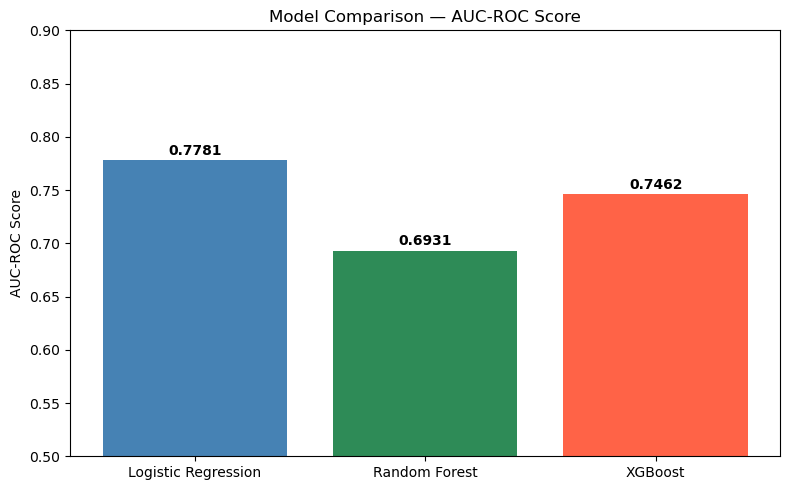

Model and scaler saved!


In [11]:
import matplotlib.pyplot as plt

# Plot AUC comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(0.5, 0.9)
plt.title('Model Comparison — AUC-ROC Score')
plt.ylabel('AUC-ROC Score')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png')
plt.show()

# Save the best model and scaler for the dashboard
import joblib
best_model = models['Logistic Regression']
joblib.dump(best_model, '../models/churn_model.pkl')
joblib.dump(scaler_full, '../models/scaler.pkl')
print("Model and scaler saved!")

Segment distribution:
segment
Lost         2400
Champion     1063
Promising    1009
Loyal         817
At Risk       589
Name: count, dtype: int64


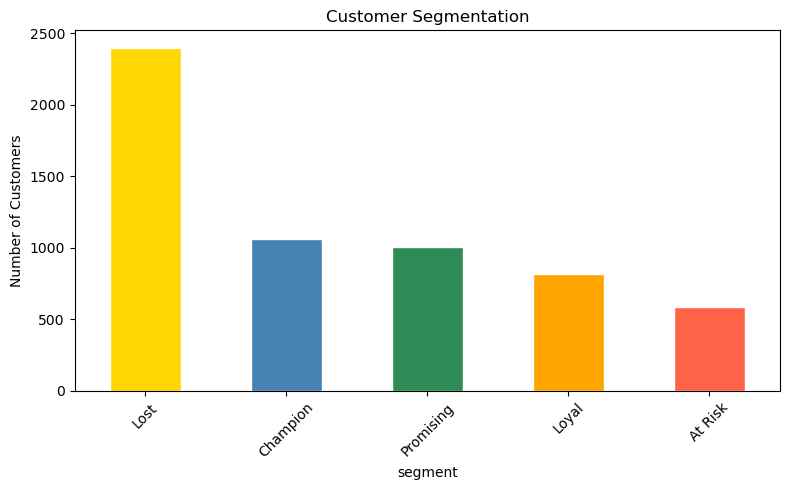


Segment profile:
           frequency  monetary  churn
segment                              
At Risk         4.96   1790.99    1.0
Champion       18.11   9724.95    0.0
Lost            2.59    973.54    1.0
Loyal           6.57   2704.51    0.0
Promising       3.18   1423.40    0.0


In [12]:
# Customer Segmentation based on RFM scores
def segment_customer(row):
    if row['recency'] <= 30 and row['frequency'] >= 5:
        return 'Champion'
    elif row['recency'] <= 60 and row['frequency'] >= 3:
        return 'Loyal'
    elif row['recency'] <= 90:
        return 'Promising'
    elif row['recency'] <= 180:
        return 'At Risk'
    else:
        return 'Lost'

rfm_full['segment'] = rfm_full.apply(segment_customer, axis=1)

print("Segment distribution:")
print(rfm_full['segment'].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
colors = ['gold', 'steelblue', 'seagreen', 'orange', 'tomato']
rfm_full['segment'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Customer Segmentation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/customer_segments.png')
plt.show()

# Average CLV and churn risk per segment
print("\nSegment profile:")
print(rfm_full.groupby('segment')[['frequency', 'monetary', 'churn']].mean().round(2))

In [13]:
# Build final master table with segments and CLV
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

summary_full = summary_data_from_transaction_data(
    df_full,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=df_full['InvoiceDate'].max()
)

returning_full = summary_full[summary_full['frequency'] > 0]

bgf = BetaGeoFitter(penalizer_coef=0.5)
bgf.fit(summary_full['frequency'], summary_full['recency'], summary_full['T'])

ggf = GammaGammaFitter(penalizer_coef=0.5)
ggf.fit(returning_full['frequency'], returning_full['monetary_value'])

summary_full['clv'] = ggf.customer_lifetime_value(
    bgf,
    summary_full['frequency'],
    summary_full['recency'],
    summary_full['T'],
    summary_full['monetary_value'],
    time=12,
    freq='D'
)
summary_full['clv'] = summary_full['clv'].fillna(0).clip(lower=0)

# Merge everything
rfm_full = rfm_full.set_index('Customer ID')
master_full = rfm_full.join(summary_full[['clv']], how='left')
master_full['clv'] = master_full['clv'].fillna(0)

# Add churn probability
master_full['churn_probability'] = best_model.predict_proba(
    scaler_full.transform(master_full[['frequency', 'monetary']])
)[:,1]

master_full.to_csv('../reports/master_customer_table_full.csv')
print("Master table saved!")
print(master_full.head(10))

C:\Users\suada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Master table saved!
             frequency  monetary  recency  churn    segment           clv  \
Customer ID                                                                 
12346               12  77556.46      326      1       Lost  46128.412426   
12347                8   4921.53        2      0   Champion   4827.678906   
12348                5   2019.40       75      0  Promising   2741.711896   
12349                4   4428.69       19      0      Loyal   5942.831771   
12350                1    334.40      310      1       Lost      0.000000   
12351                1    300.93      375      1       Lost      0.000000   
12352               10   2849.84       36      0      Loyal   2947.134795   
12353                2    406.76      204      1       Lost      0.000000   
12354                1   1079.40      232      1       Lost      0.000000   
12355                2    947.61      214      1       Lost      0.000000   

             churn_probability  
Customer ID           

In [4]:
df1 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df_full = pd.concat([df1, df2], ignore_index=True)
df_full = df_full.drop_duplicates()

print("Year 1 shape:", df1.shape)
print("Year 2 shape:", df2.shape)
print("Combined shape:", df_full.shape)

Year 1 shape: (525461, 8)
Year 2 shape: (541910, 8)
Combined shape: (1033036, 8)


In [5]:
# ── Year Comparison Analysis ──────────────────────────────

# Year 1: 2009-2010
df1_clean = df1.dropna(subset=['Customer ID'])
df1_clean = df1_clean[df1_clean['Quantity'] > 0]
df1_clean = df1_clean[df1_clean['Price'] > 0]
df1_clean['Customer ID'] = df1_clean['Customer ID'].astype(int)
df1_clean['TotalPrice'] = df1_clean['Quantity'] * df1_clean['Price']

# Year 2: 2010-2011
df2_clean = df2.dropna(subset=['Customer ID'])
df2_clean = df2_clean[df2_clean['Quantity'] > 0]
df2_clean = df2_clean[df2_clean['Price'] > 0]
df2_clean['Customer ID'] = df2_clean['Customer ID'].astype(int)
df2_clean['TotalPrice'] = df2_clean['Quantity'] * df2_clean['Price']

# Build RFM for each year separately
def build_rfm(data):
    ref = data['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = data.groupby('Customer ID').agg(
        last_purchase=('InvoiceDate', 'max'),
        frequency=('Invoice', 'nunique'),
        monetary=('TotalPrice', 'sum')
    ).reset_index()
    rfm['recency'] = (ref - rfm['last_purchase']).dt.days
    rfm = rfm.drop(columns=['last_purchase'])
    rfm['churn'] = (rfm['recency'] > 90).astype(int)
    return rfm

rfm1 = build_rfm(df1_clean)
rfm2 = build_rfm(df2_clean)

# Build comparison stats
comparison = {
    'Metric': [
        'Total Customers',
        'Churn Rate (%)',
        'Avg Order Frequency',
        'Avg Monetary Value (£)',
        'Avg Recency (days)',
        'Total Revenue (£)'
    ],
    'Year 2009-2010': [
        len(rfm1),
        round(rfm1['churn'].mean() * 100, 2),
        round(rfm1['frequency'].mean(), 2),
        round(rfm1['monetary'].mean(), 2),
        round(rfm1['recency'].mean(), 2),
        round(df1_clean['TotalPrice'].sum(), 2)
    ],
    'Year 2010-2011': [
        len(rfm2),
        round(rfm2['churn'].mean() * 100, 2),
        round(rfm2['frequency'].mean(), 2),
        round(rfm2['monetary'].mean(), 2),
        round(rfm2['recency'].mean(), 2),
        round(df2_clean['TotalPrice'].sum(), 2)
    ]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# Save for dashboard
comparison_df.to_csv('../reports/year_comparison.csv', index=False)
print("\nSaved!")

                Metric  Year 2009-2010  Year 2010-2011
       Total Customers         4312.00         4338.00
        Churn Rate (%)           33.28           33.40
   Avg Order Frequency            4.46            4.27
Avg Monetary Value (£)         2048.24         2054.27
    Avg Recency (days)           91.17           92.54
     Total Revenue (£)      8832003.27      8911425.90

Saved!


In [2]:
import pandas as pd

# Create a small sample transaction file for testing Page 2
sample = pd.DataFrame({
    'CustomerID': [1001,1001,1002,1002,1003,1004,1004,1004,1005,1006],
    'InvoiceNo': ['A1','A2','B1','B2','C1','D1','D2','D3','E1','F1'],
    'InvoiceDate': ['2023-01-05','2023-03-10','2023-02-01','2023-04-15',
                    '2022-06-01','2023-05-01','2023-06-15','2023-07-20',
                    '2022-03-01','2023-07-01'],
    'Quantity': [2,3,1,5,2,1,2,3,1,4],
    'UnitPrice': [10.5,20.0,15.0,8.5,30.0,25.0,12.0,18.0,50.0,7.5]
})

sample.to_csv('C:/Users/suada/Desktop/graduation_project/reports/test_upload.csv', index=False)
print("Test file created!")
print(sample)

Test file created!
   CustomerID InvoiceNo InvoiceDate  Quantity  UnitPrice
0        1001        A1  2023-01-05         2       10.5
1        1001        A2  2023-03-10         3       20.0
2        1002        B1  2023-02-01         1       15.0
3        1002        B2  2023-04-15         5        8.5
4        1003        C1  2022-06-01         2       30.0
5        1004        D1  2023-05-01         1       25.0
6        1004        D2  2023-06-15         2       12.0
7        1004        D3  2023-07-20         3       18.0
8        1005        E1  2022-03-01         1       50.0
9        1006        F1  2023-07-01         4        7.5
